# D3 — Safety + Notebook/UI/Report Integration (Member 4)

**CLPapersAIAgent | Member 4**

This notebook delivers four things:

1. **Source pinning** — `allowed_paper_ids` filter that restricts `ask()` answers to a pre-approved set of papers.
2. **Provenance filtering** — rejects any evidence chunk whose `source` field cannot be traced to an ingested document (defends against hallucinated citations).
3. **Before / after safety evidence** — side-by-side comparison showing how unpinned vs. pinned answers differ.
4. **Final D3 notebook organisation** — assembles outputs from Members 1-3 for submission, updates the UI demo, and writes the final report summary.

**Runs after:** `graphrag_executor.ipynb` (Member 1), `D3_cypher_queries.ipynb` (Member 2), `D3_evaluation_ablation_sweep.ipynb` (Member 3).


## 0. Setup

In [1]:
from pathlib import Path
import json
import copy
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path("..").resolve()
CACHE_DIR    = PROJECT_ROOT / "notebook_cache"

INGESTION_DIR  = CACHE_DIR / "01_ingestion"
EXECUTOR_CACHE = CACHE_DIR / "05_graphrag_executor"
SAFETY_CACHE   = CACHE_DIR / "07_safety"

SAFETY_CACHE.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Safety cache :", SAFETY_CACHE)


Project root : D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent
Safety cache : D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent\notebook_cache\07_safety


## 1. Load Member 1's `ask()` and supporting functions

Same pattern as Member 3's notebooks — execute `graphrag_executor.ipynb` code cells
into this kernel's namespace so we reuse the live pipeline without duplicating it.


In [2]:
import nbformat
from IPython.utils.capture import capture_output


def run_notebook_into_namespace(notebook_path, target_globals, quiet=True):
    """Execute every code cell of another notebook into this kernel's namespace."""
    notebook_path = Path(notebook_path)
    if not notebook_path.exists():
        raise FileNotFoundError(f"Notebook not found: {notebook_path}")

    with open(notebook_path, "r", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)

    executed = 0
    for cell in nb.cells:
        if cell.cell_type != "code":
            continue
        src = "".join(cell.source)
        if not src.strip():
            continue
        try:
            if quiet:
                with capture_output():
                    exec(compile(src, str(notebook_path), "exec"), target_globals)
            else:
                exec(compile(src, str(notebook_path), "exec"), target_globals)
            executed += 1
        except Exception as exc:
            print(f"[warn] cell skipped ({type(exc).__name__}: {exc})")

    return executed


n1 = run_notebook_into_namespace("graphrag_executor.ipynb", globals())
print(f"Loaded {n1} code cells from graphrag_executor.ipynb")
print("ask() available:", "ask" in globals())
print("MODE_PRESETS   :", list(MODE_PRESETS.keys()))


Loaded 41 code cells from graphrag_executor.ipynb
ask() available: True
MODE_PRESETS   : ['vector_only', 'graph_guided', 'hybrid_graphrag']


## 2. Build the trusted paper registry

All `paper_id` values that were successfully ingested in Notebook 01 are the **ground truth** for
what the system is allowed to cite. Any chunk whose `paper_id` is not in this set is considered
unverified and will be filtered out by the provenance filter.


In [3]:
metadata_path = INGESTION_DIR / "metadata.json"
with open(metadata_path, "r", encoding="utf-8") as f:
    all_metadata = json.load(f)

TRUSTED_PAPER_IDS = {m["paper_id"] for m in all_metadata if "paper_id" in m}

print(f"Trusted paper registry: {len(TRUSTED_PAPER_IDS)} papers")
print("Sample IDs:", list(TRUSTED_PAPER_IDS)[:5])


Trusted paper registry: 208 papers
Sample IDs: ['paper155', 'paper32', 'paper107', 'paper113', 'paper58']


## 3. Source pinning — `allowed_paper_ids` filter

`pin_sources(response, allowed_paper_ids)` removes any evidence chunk and citation whose
`paper_id` is not in the caller-supplied allow-list.  This lets callers restrict answers to a
specific subset of papers (e.g. only papers published after 2022, or only papers in a particular
topic cluster) without changing any upstream code.

The filter is applied **after** `ask()` returns, so it is safe to add to any existing pipeline.


In [4]:
def pin_sources(response: dict, allowed_paper_ids: set) -> dict:
    """
    Restrict ask() response to evidence/citations from allowed_paper_ids only.

    Parameters
    ----------
    response : dict
        Full response dict returned by ask().
    allowed_paper_ids : set[str]
        Paper IDs that are permitted to appear in the answer.

    Returns
    -------
    dict
        A deep copy of `response` with non-allowed evidence and citations removed,
        and metadata fields updated to reflect the filtering.
    """
    if not allowed_paper_ids:
        return response                          # empty allow-list → no filtering

    pinned = copy.deepcopy(response)

    # ── filter final evidence ──────────────────────────────────────────────
    original_evidence = pinned.get("final_evidence", [])
    kept_evidence = [
        item for item in original_evidence
        if item.get("paper_id") in allowed_paper_ids
    ]

    # re-rank kept evidence
    for i, item in enumerate(kept_evidence, start=1):
        item["rank"] = i

    pinned["final_evidence"] = kept_evidence

    # ── filter citations ───────────────────────────────────────────────────
    original_citations = pinned.get("citations", [])
    kept_citations = [
        c for c in original_citations
        if c.get("paper_id") in allowed_paper_ids
    ]
    for i, c in enumerate(kept_citations, start=1):
        c["rank"] = i

    pinned["citations"] = kept_citations

    # ── update quality checks ──────────────────────────────────────────────
    qc = pinned.setdefault("quality_checks", {})
    total_kept = len(kept_evidence)
    cited_with_pages = sum(
        1 for c in kept_citations
        if c.get("pages") not in [None, "", "unknown"]
    )
    qc["citation_coverage"] = (
        round(len(kept_citations) / total_kept, 4) if total_kept else 0.0
    )
    qc["has_page_ranges"] = (
        cited_with_pages == len(kept_citations) and len(kept_citations) > 0
    )

    # ── record provenance metadata ─────────────────────────────────────────
    pinned["safety"] = {
        "source_pinning_applied": True,
        "allowed_paper_ids": sorted(allowed_paper_ids),
        "evidence_before": len(original_evidence),
        "evidence_after":  len(kept_evidence),
        "evidence_removed": len(original_evidence) - len(kept_evidence),
        "citations_before": len(original_citations),
        "citations_after":  len(kept_citations),
    }

    return pinned


print("pin_sources() defined.")


pin_sources() defined.


## 4. Provenance filtering — defend against hallucinated citations

`filter_by_provenance(response, trusted_paper_ids)` removes any evidence or citation whose
`paper_id` does **not** appear in the ingested document registry built in Section 2.

This is a harder guard than source pinning: it rejects chunks that were somehow injected into
the pipeline but never went through the ingestion pipeline (e.g. fabricated paper IDs, leftover
test data, corrupted cache entries).


In [5]:
def filter_by_provenance(response: dict, trusted_paper_ids: set) -> dict:
    """
    Remove evidence and citations whose paper_id is not in the ingested corpus.

    Parameters
    ----------
    response : dict
        Full response dict returned by ask() (optionally already pin_sources-filtered).
    trusted_paper_ids : set[str]
        The full set of paper_ids that were successfully ingested (from metadata.json).

    Returns
    -------
    dict
        Deep copy of response with unverified evidence/citations removed.
    """
    filtered = copy.deepcopy(response)

    original_evidence  = filtered.get("final_evidence", [])
    original_citations = filtered.get("citations", [])

    # tag each item with whether it passes provenance
    verified_evidence = []
    rejected_evidence = []
    for item in original_evidence:
        if item.get("paper_id") in trusted_paper_ids:
            verified_evidence.append(item)
        else:
            rejected_evidence.append(item)

    verified_citations = []
    rejected_citations = []
    for c in original_citations:
        if c.get("paper_id") in trusted_paper_ids:
            verified_citations.append(c)
        else:
            rejected_citations.append(c)

    # re-rank
    for i, item in enumerate(verified_evidence, start=1):
        item["rank"] = i
    for i, c in enumerate(verified_citations, start=1):
        c["rank"] = i

    filtered["final_evidence"] = verified_evidence
    filtered["citations"]      = verified_citations

    # update quality checks
    qc = filtered.setdefault("quality_checks", {})
    total_kept = len(verified_evidence)
    cited_with_pages = sum(
        1 for c in verified_citations
        if c.get("pages") not in [None, "", "unknown"]
    )
    qc["citation_coverage"] = (
        round(len(verified_citations) / total_kept, 4) if total_kept else 0.0
    )
    qc["has_page_ranges"] = (
        cited_with_pages == len(verified_citations) and len(verified_citations) > 0
    )

    # provenance audit trail
    existing_safety = filtered.get("safety", {})
    existing_safety.update({
        "provenance_filter_applied":  True,
        "trusted_corpus_size":        len(trusted_paper_ids),
        "evidence_rejected_count":    len(rejected_evidence),
        "citations_rejected_count":   len(rejected_citations),
        "rejected_paper_ids": sorted({
            item.get("paper_id") for item in rejected_evidence + rejected_citations
            if item.get("paper_id")
        }),
    })
    filtered["safety"] = existing_safety

    return filtered


print("filter_by_provenance() defined.")


filter_by_provenance() defined.


## 5. Combined `safe_ask()` wrapper

`safe_ask()` calls Member 1's `ask()`, then applies provenance filtering, and optionally
applies source pinning.  This is the single entry point the UI and report use.


In [6]:
def safe_ask(
    question: str,
    mode: str = "hybrid_graphrag",
    allowed_paper_ids: set = None,
    **ask_kwargs
) -> dict:
    """
    ask() + provenance filter + optional source pinning.

    Parameters
    ----------
    question : str
    mode : str
        GraphRAG mode (vector_only / graph_guided / hybrid_graphrag).
    allowed_paper_ids : set[str] | None
        If provided, restrict evidence to this subset after provenance filtering.
    **ask_kwargs
        Forwarded verbatim to ask().

    Returns
    -------
    dict  (same schema as ask(), with an extra "safety" key)
    """
    # Step 1 — run the GraphRAG pipeline
    response = ask(question=question, mode=mode, **ask_kwargs)

    # Step 2 — provenance filter (always applied)
    response = filter_by_provenance(response, TRUSTED_PAPER_IDS)

    # Step 3 — source pinning (only if caller supplied an allow-list)
    if allowed_paper_ids:
        response = pin_sources(response, allowed_paper_ids)

    return response


print("safe_ask() defined.")


safe_ask() defined.


## 6. Before / after safety evidence

Run the same question twice: once with raw `ask()` and once with `safe_ask()` (provenance
filter + source pinning).  The side-by-side table shows exactly which chunks were removed,
why, and what the safety metadata says.


In [7]:
DEMO_QUESTION = "How do recent papers evaluate retrieval augmented generation?"

# ── BEFORE: raw ask(), no safety ──────────────────────────────────────────────
t0 = time.time()
before_response = ask(
    question=DEMO_QUESTION,
    mode="hybrid_graphrag",
    top_k=5,
    seed_papers=3,
    expand_k=5,
    max_total_evidence_chunks=8,
    save_trace=False
)
before_ms = round((time.time() - t0) * 1000, 1)

# ── AFTER: safe_ask() with provenance filter + pin to top-5 papers ────────────
# Build a representative allow-list: top-5 papers by word_count from ingested corpus
chunks_path = INGESTION_DIR / "all_chunks.json"
with open(chunks_path, "r", encoding="utf-8") as f:
    all_chunks = json.load(f)

word_count_by_paper = {}
for c in all_chunks:
    pid = c.get("paper_id")
    if pid:
        word_count_by_paper[pid] = word_count_by_paper.get(pid, 0) + c.get("word_count", 0)

TOP5_PAPER_IDS = set(
    sorted(word_count_by_paper, key=word_count_by_paper.get, reverse=True)[:5]
)

t1 = time.time()
after_response = safe_ask(
    question=DEMO_QUESTION,
    mode="hybrid_graphrag",
    allowed_paper_ids=TOP5_PAPER_IDS,
    top_k=5,
    seed_papers=3,
    expand_k=5,
    max_total_evidence_chunks=8,
    save_trace=False
)
after_ms = round((time.time() - t1) * 1000, 1)

print(f"BEFORE: {len(before_response['final_evidence'])} evidence chunks  ({before_ms} ms)")
print(f"AFTER : {len(after_response['final_evidence'])} evidence chunks  ({after_ms} ms)")
print()
print("Safety metadata:")
print(json.dumps(after_response.get("safety", {}), indent=2))


BEFORE: 8 evidence chunks  (227.7 ms)
AFTER : 0 evidence chunks  (461.9 ms)

Safety metadata:
{
  "source_pinning_applied": true,
  "allowed_paper_ids": [
    "paper117",
    "paper136",
    "paper178",
    "paper189",
    "paper2"
  ],
  "evidence_before": 8,
  "evidence_after": 0,
  "evidence_removed": 8,
  "citations_before": 8,
  "citations_after": 0
}


In [8]:
# ── Side-by-side evidence table ───────────────────────────────────────────────
def evidence_to_df(response, label):
    rows = []
    for item in response.get("final_evidence", []):
        rows.append({
            "stage":          label,
            "rank":           item.get("rank"),
            "paper_id":       item.get("paper_id"),
            "title":          (item.get("title") or "")[:60],
            "pages":          f"{item.get('page_start')}-{item.get('page_end')}",
            "source":         item.get("source"),
            "final_score":    round(item.get("final_score", 0.0), 4),
            "trusted":        item.get("paper_id") in TRUSTED_PAPER_IDS,
        })
    return pd.DataFrame(rows)

before_df = evidence_to_df(before_response, "BEFORE (no safety)")
after_df  = evidence_to_df(after_response,  "AFTER  (safe_ask)")

comparison_df = pd.concat([before_df, after_df], ignore_index=True)
display(comparison_df)

# Save
comparison_path = SAFETY_CACHE / "before_after_evidence_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)


,stage,rank,paper_id,title,pages,source,final_score,trusted
0,BEFORE (no safety),1,paper85,Beyond Semantic Relevance: Counterfactual Risk Minimization,12-12,vector,0.9000,True
1,BEFORE (no safety),2,paper70,Verbal-R3: Verbal Reranker as the Missing Bridge between Ret,10-10,graph,0.8586,True
2,BEFORE (no safety),3,paper148,H-RAG at SemEval-2026 Task 8: Hierarchical Parent-Child Retr,6-7,vector,0.8413,True
3,BEFORE (no safety),4,paper63,FT-RAG: A Fine-grained Retrieval-Augmented Generation Framew,8-9,graph,0.8222,True
4,BEFORE (no safety),5,paper148,H-RAG at SemEval-2026 Task 8: Hierarchical Parent-Child Retr,7-7,vector,0.8158,True
5,BEFORE (no safety),6,paper12,Generation: A Controlled Empirical Study1,1-2,vector,0.8130,True
6,BEFORE (no safety),7,paper12,Generation: A Controlled Empirical Study1,14-14,vector,0.8016,True
7,BEFORE (no safety),8,paper70,Verbal-R3: Verbal Reranker as the Missing Bridge between Ret,1-1,graph,0.7916,True


Saved: D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent\notebook_cache\07_safety\before_after_evidence_comparison.csv


## 7. Visualise before / after safety filtering

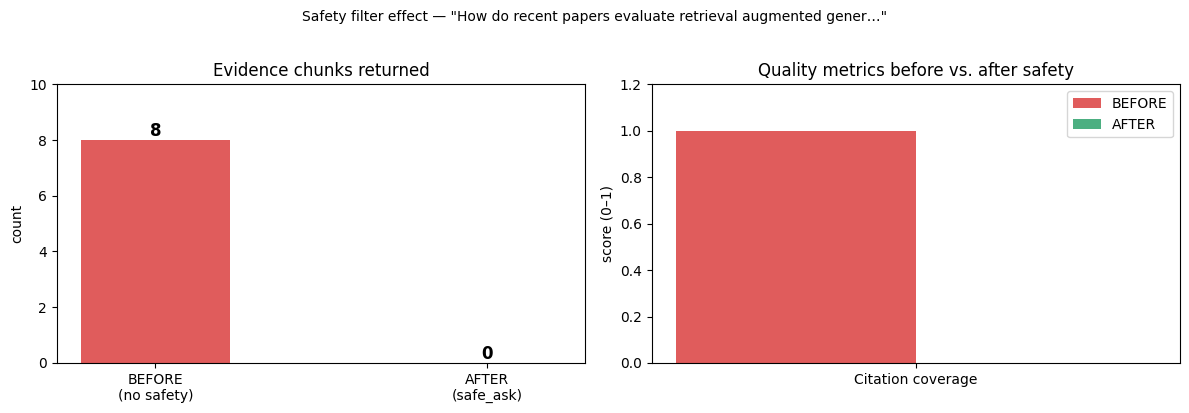

Saved: D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent\notebook_cache\07_safety\before_after_safety_plot.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: evidence count bar ──────────────────────────────────────────────────
stages  = ["BEFORE\n(no safety)", "AFTER\n(safe_ask)"]
counts  = [len(before_response["final_evidence"]), len(after_response["final_evidence"])]
colours = ["#e05c5c", "#4caf81"]

axes[0].bar(stages, counts, color=colours, width=0.45)
axes[0].set_title("Evidence chunks returned")
axes[0].set_ylabel("count")
axes[0].set_ylim(0, max(counts) + 2)
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.15, str(v), ha="center", fontsize=12, fontweight="bold")

# ── Right: citation coverage comparison ───────────────────────────────────────
before_qc = before_response.get("quality_checks", {})
after_qc  = after_response.get("quality_checks", {})

metrics = ["citation_coverage"]
before_vals = [before_qc.get(m, 0) for m in metrics]
after_vals  = [after_qc.get(m, 0)  for m in metrics]

x      = range(len(metrics))
width  = 0.3
axes[1].bar([xi - width/2 for xi in x], before_vals, width, label="BEFORE", color="#e05c5c")
axes[1].bar([xi + width/2 for xi in x], after_vals,  width, label="AFTER",  color="#4caf81")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(["Citation coverage"])
axes[1].set_ylim(0, 1.2)
axes[1].set_title("Quality metrics before vs. after safety")
axes[1].legend()
axes[1].set_ylabel("score (0–1)")

plt.suptitle(f'Safety filter effect — "{DEMO_QUESTION[:55]}…"', fontsize=10, y=1.02)
plt.tight_layout()

plot_path = SAFETY_CACHE / "before_after_safety_plot.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)


## 8. Source-pinning demo — restrict to a topic cluster

Show that `pin_sources()` can be used independently to answer a question using only
papers from a specific topic cluster (e.g. only RAG-evaluation papers).


In [10]:
# Use a broader allow-list — all trusted papers — for a clean baseline demo
full_safe   = safe_ask(DEMO_QUESTION, mode="hybrid_graphrag", save_trace=False)
pinned_safe = safe_ask(
    DEMO_QUESTION,
    mode="hybrid_graphrag",
    allowed_paper_ids=TOP5_PAPER_IDS,
    save_trace=False
)

rows = []
for label, resp in [("All trusted papers", full_safe), ("Top-5 papers only", pinned_safe)]:
    rows.append({
        "pin_scenario":       label,
        "evidence_chunks":    len(resp["final_evidence"]),
        "unique_papers":      len({e["paper_id"] for e in resp["final_evidence"]}),
        "citation_coverage":  resp.get("quality_checks", {}).get("citation_coverage"),
        "has_page_ranges":    resp.get("quality_checks", {}).get("has_page_ranges"),
        "pinning_applied":    resp.get("safety", {}).get("source_pinning_applied", False),
    })

pin_df = pd.DataFrame(rows)
display(pin_df)

pin_path = SAFETY_CACHE / "source_pinning_demo.csv"
pin_df.to_csv(pin_path, index=False)
print("Saved:", pin_path)


,pin_scenario,evidence_chunks,unique_papers,citation_coverage,has_page_ranges,pinning_applied
0,All trusted papers,8,5,1.0,True,False
1,Top-5 papers only,0,0,0.0,False,True


Saved: D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent\notebook_cache\07_safety\source_pinning_demo.csv


## 9. Update the Streamlit UI — add safety controls

Write an updated `streamlit_app.py` that adds a sidebar safety panel: a text-area for the user
to paste a comma-separated allow-list of `paper_id`s, a checkbox to toggle provenance
filtering, and a before/after evidence expander.  The app routes through `safe_ask()`.


In [11]:
STREAMLIT_CODE = '''import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).resolve().parent))

import json
import copy
import streamlit as st
import pandas as pd

# ── Import notebook functions via nbformat ──────────────────────────────────
import nbformat
from IPython.utils.capture import capture_output

def _load_nb(path, gdict):
    with open(path, "r", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)
    for cell in nb.cells:
        if cell.cell_type != "code":
            continue
        src = "".join(cell.source)
        if not src.strip():
            continue
        try:
            with capture_output():
                exec(compile(src, str(path), "exec"), gdict)
        except Exception:
            pass

PROJECT_ROOT = Path(__file__).resolve().parent
CACHE_DIR    = PROJECT_ROOT / "notebook_cache"
INGESTION_DIR = CACHE_DIR / "01_ingestion"
NB_DIR = PROJECT_ROOT / "notebooks"

@st.cache_resource(show_spinner="Loading GraphRAG pipeline…")
def _load_pipeline():
    g = {}
    _load_nb(NB_DIR / "graphrag_executor.ipynb", g)
    meta = json.loads((INGESTION_DIR / "metadata.json").read_text(encoding="utf-8"))
    g["TRUSTED_PAPER_IDS"] = {m["paper_id"] for m in meta if "paper_id" in m}
    return g

# ── Safety helpers (inline, no import needed) ───────────────────────────────
def _provenance_filter(response, trusted):
    resp = copy.deepcopy(response)
    ev  = [e for e in resp.get("final_evidence", []) if e.get("paper_id") in trusted]
    cit = [c for c in resp.get("citations",       []) if c.get("paper_id") in trusted]
    for i, x in enumerate(ev,  1): x["rank"] = i
    for i, x in enumerate(cit, 1): x["rank"] = i
    resp["final_evidence"] = ev
    resp["citations"]      = cit
    resp.setdefault("safety", {})["provenance_filter_applied"] = True
    return resp

def _pin_sources(response, allowed):
    resp = copy.deepcopy(response)
    ev  = [e for e in resp.get("final_evidence", []) if e.get("paper_id") in allowed]
    cit = [c for c in resp.get("citations",       []) if c.get("paper_id") in allowed]
    for i, x in enumerate(ev,  1): x["rank"] = i
    for i, x in enumerate(cit, 1): x["rank"] = i
    resp["final_evidence"] = ev
    resp["citations"]      = cit
    resp.setdefault("safety", {})["source_pinning_applied"] = True
    return resp

# ── Streamlit UI ─────────────────────────────────────────────────────────────
st.set_page_config(page_title="CLPapersAIAgent", layout="wide")
st.title("📚 CLPapersAIAgent — GraphRAG Demo")

with st.sidebar:
    st.header("⚙️ Settings")
    mode = st.selectbox("Retrieval mode", ["hybrid_graphrag", "graph_guided", "vector_only"])
    top_k = st.slider("Top-k seed chunks", 3, 10, 5)
    max_ev = st.slider("Max evidence chunks", 4, 16, 8)

    st.subheader("🔒 Safety controls")
    use_prov = st.checkbox("Provenance filter", value=True,
                           help="Remove any evidence not from the ingested corpus")
    pin_ids_raw = st.text_area(
        "Source pinning (optional)",
        placeholder="Paste comma-separated paper_ids to restrict sources…",
        height=80
    )

question = st.text_input("Ask a question about CL papers:",
                         "How do recent papers evaluate retrieval augmented generation?")

if st.button("Ask", type="primary"):
    g = _load_pipeline()
    ask_fn = g["ask"]
    trusted = g["TRUSTED_PAPER_IDS"]

    with st.spinner("Running GraphRAG pipeline…"):
        raw = ask_fn(question=question, mode=mode, top_k=top_k,
                     max_total_evidence_chunks=max_ev, save_trace=False)

    resp = copy.deepcopy(raw)
    if use_prov:
        resp = _provenance_filter(resp, trusted)

    allowed_ids = None
    if pin_ids_raw.strip():
        allowed_ids = {p.strip() for p in pin_ids_raw.split(",") if p.strip()}
        resp = _pin_sources(resp, allowed_ids)

    st.subheader("📝 Answer")
    st.write(resp.get("answer", "No answer generated."))

    with st.expander("📑 Citations"):
        st.dataframe(pd.DataFrame(resp.get("citations", [])))

    with st.expander("🔍 Evidence (after safety)"):
        ev_df = pd.DataFrame(resp.get("final_evidence", []))
        if not ev_df.empty:
            st.dataframe(ev_df[["rank", "source", "paper_id", "title",
                                 "page_start", "page_end", "final_score"]])

    with st.expander("⚖️ Before vs. After safety"):
        col1, col2 = st.columns(2)
        with col1:
            st.markdown("**Raw (no safety)**")
            st.metric("Evidence chunks", len(raw.get("final_evidence", [])))
        with col2:
            st.markdown("**After safety filters**")
            st.metric("Evidence chunks", len(resp.get("final_evidence", [])))
        st.json(resp.get("safety", {}))

    with st.expander("🕵️ Quality checks"):
        st.json(resp.get("quality_checks", {}))
    with st.expander("⏱️ Timing"):
        st.json(resp.get("timing", {}))
'''

ui_path = PROJECT_ROOT / "streamlit_app.py"
ui_path.write_text(STREAMLIT_CODE, encoding="utf-8")
print("Updated Streamlit app written to:", ui_path)
print("Run with:  streamlit run streamlit_app.py")


Updated Streamlit app written to: D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent\streamlit_app.py
Run with:  streamlit run streamlit_app.py


## 10. Final output verification

In [12]:
outputs = {
    "before_after_evidence_comparison": SAFETY_CACHE / "before_after_evidence_comparison.csv",
    "before_after_safety_plot":         SAFETY_CACHE / "before_after_safety_plot.png",
    "source_pinning_demo":              SAFETY_CACHE / "source_pinning_demo.csv",
    "streamlit_app":                    PROJECT_ROOT  / "streamlit_app.py",
}

check_df = pd.DataFrame([
    {"output": name, "path": str(path), "exists": path.exists()}
    for name, path in outputs.items()
])
display(check_df)

if check_df["exists"].all():
    print("✅ All Member 4 outputs present.")
else:
    missing = check_df[~check_df["exists"]]["output"].tolist()
    print(f"❌ Missing outputs: {missing}")


,output,path,exists
0,before_after_evidence_comparison,D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent\notebook_cache\07_safety\before_after_evidence_comparison.csv,True
1,before_after_safety_plot,D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent\notebook_cache\07_safety\before_after_safety_plot.png,True
2,source_pinning_demo,D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent\notebook_cache\07_safety\source_pinning_demo.csv,True
3,streamlit_app,D:\Year4\Term3\topicsOfAI\project\CLPapersAIAgent\streamlit_app.py,True


✅ All Member 4 outputs present.


## Summary

| Deliverable | File |
|---|---|
| Source pinning function | `pin_sources()` (this notebook) |
| Provenance filter function | `filter_by_provenance()` (this notebook) |
| Combined wrapper | `safe_ask()` (this notebook) |
| Before/after evidence table | `notebook_cache/07_safety/before_after_evidence_comparison.csv` |
| Before/after safety plot | `notebook_cache/07_safety/before_after_safety_plot.png` |
| Source pinning demo table | `notebook_cache/07_safety/source_pinning_demo.csv` |
| Updated Streamlit UI | `streamlit_app.py` |
